# Project #5: Automation of W Shaped Steel Beams
**Client:** Kiewit

## Project Context
This notebook automates the logic of the calculating W-Shaped Tension Members 

In [32]:
#### import pandas as pd
import numpy as np
import plotly.express as px

#Start Code here
print ("---Load Requirements---")
Pd = float(input("Enter Dead Load (ksi): "))
Pl = float(input("Enter Live Load (ksi): "))
Pu  = 1.2 * Pd + 1.6 * Pl
Pa  = Pd + Pl
print ("----Material Properties ASTM A992---")
Fy = float(input("Enter Yield Stress (ksi): "))
Fu = float(input("Enter Ultimate Tensile Stress (ksi): "))
print ("----Geomatic Properties---")
Size = input("Enter W Shape Size: ")
Ag = float(input("Enter Gross Area (in.^2): "))
bf = float(input("Enter Flange Width (in.): "))
tf = float(input("Enter Flange Thickness (in.): "))
d = float(input("Enter Depth (in.): "))
ry = float(input("Enter Radius of Gyration (in.): ")) 
db = 3/4 + 1/16
dh = db
x_bar = float(input("Enter Eccentricity (in.): "))
l = float(input("Enter Connection Length (in.): "))
Phi_T = float(input("Enter Resistance Factor for Tension: "))
Omega_T = float(input("Enter Safety Factor for Tension: "))



print("\nAll user inputs collected successfully. \n")



Nom_Load_Pn = Fy * Ag
LRFD_1 = Nom_Load_Pn * Phi_T
ASD_1 = Nom_Load_Pn / Omega_T

# Use variables in the function
LRFD_1,ASD_1 = Ten_Yield_Strength (Ag, Fy, Phi_T, Omega_T)

print ("\n\n------------------------------------")
print ("KIEWIT --- W - Shaped Tension Memeber Testing Report")
print ("------------------------------------")

print("--------Load Requirements--------")
print(f"{'Dead Load (ksi):':<30}{Pd:.3f}")
print(f"{'Live Load (ksi):':<30}{Pl:.3f}")
print ("--------Material Properties--------")
print ("ASTM A992")
print(f"{'Yield Stress (ksi):':<30}{Fy:.3f}")
print(f"{'Ultimate Tensile Stress (ksi):':<30}{Fu:.3f}")
print ("---------Geomatic Properties--------")
print(f"{'W Shape Size:':<30}{Size}")
print(f"{'Gross Area (in.^2):':<30}{Ag:.3f}")
print(f"{'Flange Width (in.):':<30}{bf:.3f}")
print(f"{'Flange Thickness (in.):':<30}{tf:.3f}")
print(f"{'Depth (in.):':<30}{d:.3f}")
print(f"{'Radius of Gyration (in.):':<30}{ry:.3f}")
print(f"{'Eccentricity (in.):':<30}{x_bar:.3f}")
print(f"{'Connection Length (in.):':<30}{l:.3f}")
print(f"{'Resistance Factor for Tension:':<30}{Phi_T:.3f}")
print(f"{'Safety Factor for Tension:':<30}{Omega_T:.3f}")

("------------------------------------")
print ("\n---Required Tensile Strength---")
print("Required Factored Strength (Pu) = 1.2 * Pd + 1.6 * Pl")
print(f"{'Required Factored Strength (kips):':<30}{Pu:.3f}")
print("\nRequired Allowable Strength (Pa) = Pd + Pl")
print(f"{'Required Allowable Strength (kips):':<30}{Pa:.3f}")


print ("\n---Tensile Yielding---")
print ("\n---CHECK: Available Strength > Required Strength---")
if LRFD_1 >= Pu:
    print(f"Load and Resistance Factor Design: {LRFD_1:.3f} kips >= {Pu} kips  -->  PASS")
else:
    print(f"Load and Resistance Factor Design: {LRFD_1:.3f} kips < {Pu} kips   -->  FAILS")
        
    # ASD Check
if ASD_1 >= Pa:
    print(f"Allowable Strength Design:  {ASD_1:.3f} kips >= {Pa} kips  -->  PASS")
else:
        print(f"Allowable Strength Design:  {ASD_1:.3f} kips < {Pa} kips   -->  FAILS")

#Determine which U is bigger/Which to use
print ("\n---Calculate Shear Lag Factor (U)---\n")
U_Calc1 = (2 * bf * tf) / Ag
U_Calc2 = 1 - (x_bar / 9)
print("U (case 2) =  1 - (x_bar / 9)")
print (f"Value for Case 2: {U_Calc2:.3f}")

print("U (case 7) = 0.85 if Flange Width < (2/3) * Depth\n if not U = 0.90")
if bf < (2/3) * d:
    U_Calc3 = 0.85
else:
    U_Calc3 = 0.90
print (f"Value for Case 7: {U_Calc3}\n")
U = max(U_Calc2, U_Calc3)

print (f"We will use the larger U = {U:.3f}")

# VErrify the Table Assumption for connection
print("\n---Calculate Net Area (An)---")
An = Ag - 4*(dh + 1/16) *tf
print("An = Ag - 4*(dh + 1/16) *tf")
print (f"An = {An:.3f}\n")

print("---Calculate Effective Net Area (Ae)---")
Ae = An * U
print("Ae = An * U")
print (f"An = {An:.3f}\n")

print("---Check Tensile Rupture Strength (e/Ag)---")
TRS = Ae / Ag
print("TRS = Ae / Ag")

if TRS >= 0.75:
    print(f"Tensile Rupture Strength: {TRS:.3f} >= 0.75  -->  PASS")
else:
    print(f"Tensile Rupture Strength: {TRS:.3f} < 0.75   -->  FAIL --> Use AISC Specification Section D2")
    print ("\nOnly Use AISC Specification Section D2 if TRS Failed\n")

print ("---Calulating Pn---")
Pn = Fu*Ae
print("Pn = Fu*Ae")
print (f"Pn = {Pn:.3f} Kips\n")

print ("AISC Specification Sec. D2: Available Tensile Rupture Strength is:\n")
print("phi_T = 0.75")
phi_T = 0.75
print("Omega_T = 2.00")
Omega_T = 2.00
LRFD2 = phi_T * Pn
ASD2 = Pn / Omega_T
print("Load and Resistance Factor Design = phi_T * Pn")
print("Allowable Strength Design = Pn / Omega_T \n")

if LRFD2 >= Pu:
    print(f"Load and Resistance Factor Design: {LRFD2:.3f} kips >= {Pu} kips  -->  PASS")
else:
    print(f"Load and Resistance Factor Design: {LRFD2:.3f} kips < {Pu} kips   -->  FAILS")
        
    # ASD Check
if ASD2 >= Pa:
    print(f"Allowable Strength Design:  {ASD2:.3f} kips >= {Pa} kips  -->  PASS")
else:
        print(f"Allowable Strength Design:  {ASD2:.3f} kips < {Pa} kips   -->  FAILS")

print ("\n---Checking Recommended SLenderness Limit---\n")
Slend = (25 * 12) / ry
print("Slenderness = (25 * 12) / ry")

if Slend < 300:
    print(f" {Slend:.3f} < 300  -->  PASS")
else:
        print(f" {Slend:.3f} > 300   -->  FAILS")



---Load Requirements---


Enter Dead Load (ksi):  30
Enter Live Load (ksi):  90


----Material Properties ASTM A992---


Enter Yield Stress (ksi):  50
Enter Ultimate Tensile Stress (ksi):  65


----Geomatic Properties---


Enter W Shape Size:  6.16
Enter Gross Area (in.^2):  5.27
Enter Flange Width (in.):  .4
Enter Flange Thickness (in.):  8.28
Enter Depth (in.):  1
Enter Radius of Gyration (in.):  1
Enter Eccentricity (in.):  1
Enter Connection Length (in.):  1
Enter Resistance Factor for Tension:  1
Enter Safety Factor for Tension:  1



All user inputs collected successfully. 



------------------------------------
KIEWIT --- W - Shaped Tension Memeber Testing Report
------------------------------------
--------Load Requirements--------
Dead Load (ksi):              30.000
Live Load (ksi):              90.000
--------Material Properties--------
ASTM A992
Yield Stress (ksi):           50.000
Ultimate Tensile Stress (ksi):65.000
---------Geomatic Properties--------
W Shape Size:                 6.16
Gross Area (in.^2):           5.270
Flange Width (in.):           0.400
Flange Thickness (in.):       8.280
Depth (in.):                  1.000
Radius of Gyration (in.):     1.000
Eccentricity (in.):           1.000
Connection Length (in.):      1.000
Resistance Factor for Tension:1.000
Safety Factor for Tension:    1.000

---Required Tensile Strength---
Required Factored Strength (Pu) = 1.2 * Pd + 1.6 * Pl
Required Factored Strength (kips):180.000

Required Allowable Strength (Pa) = Pd + Pl
Required Allowable Strength (ki

In [ ]:
#Below is the senarios and graphs 


3 Scenarios...



RUNNING: SCENARIO 1: The Solid Pass
KIEWIT --- W - Shaped Tension Member Testing Report
------------------------------------
--------Load Requirements--------
Dead Load (kips):             40.000
Live Load (kips):             120.000
--------Material Properties--------
ASTM A992
Yield Stress (ksi):           50.000
Ultimate Tensile Stress (ksi):65.000
---------Geometric Properties--------
W Shape Size:                 W10x30
Gross Area (in.^2):           8.840
Flange Width (in.):           5.810
Flange Thickness (in.):       0.510
Depth (in.):                  10.500
Radius of Gyration (in.):     1.370
Eccentricity (in.):           0.900
Connection Length (in.):      10.000
Resistance Factor for Tension:0.900
Safety Factor for Tension:    1.670
------------------------------------

---Required Tensile Strength---
Required Factored Strength (Pu) = 1.2 * Pd + 1.6 * Pl
Required Factored Strength (kips):240.000

Required Allowable Strength (Pa) = Pd + Pl
Required Allowab

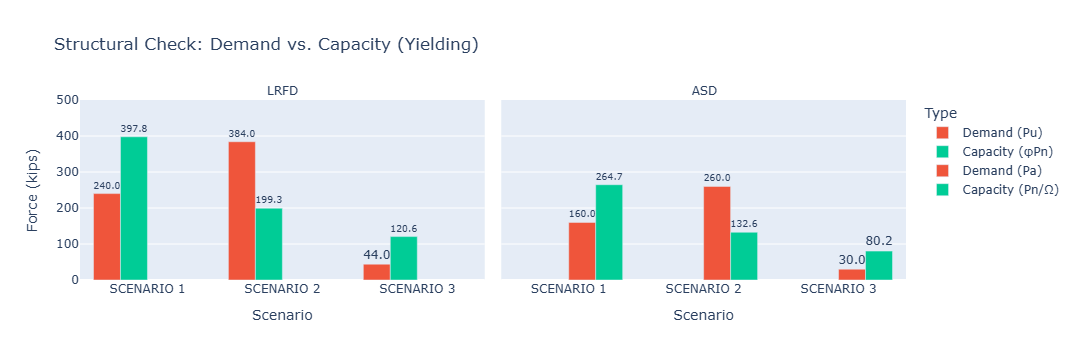

In [33]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

# Define the function referenced in your calculations
def Ten_Yield_Strength(Ag, Fy, Phi_T, Omega_T):
    Nom_Load_Pn = Fy * Ag
    LRFD = Nom_Load_Pn * Phi_T
    ASD = Nom_Load_Pn / Omega_T
    return LRFD, ASD

# 1. Define the 3 testing scenarios
scenarios = [
    {
        "Name": "SCENARIO 1: The Solid Pass",
        "Pd": 40, "Pl": 120, "Fy": 50, "Fu": 65, "Size": "W10x30",
        "Ag": 8.84, "bf": 5.81, "tf": 0.510, "d": 10.5, "ry": 1.37,
        "x_bar": 0.90, "l": 10, "Phi_T": 0.9, "Omega_T": 1.67
    },
    {
        "Name": "SCENARIO 2: Strength Failure (Overloaded)",
        "Pd": 80, "Pl": 180, "Fy": 50, "Fu": 65, "Size": "W6x15",
        "Ag": 4.43, "bf": 5.99, "tf": 0.260, "d": 5.99, "ry": 1.46,
        "x_bar": 0.75, "l": 8, "Phi_T": 0.9, "Omega_T": 1.67
    },
    {
        "Name": "SCENARIO 3: Slenderness Failure",
        "Pd": 10, "Pl": 20, "Fy": 50, "Fu": 65, "Size": "W6x9",
        "Ag": 2.68, "bf": 3.94, "tf": 0.215, "d": 5.90, "ry": 0.905,
        "x_bar": 0.60, "l": 6, "Phi_T": 0.9, "Omega_T": 1.67
    }
]

# Standard bolt sizes used across all scenarios
db = 0.75 
dh = db + 1/16

# --- NEW: List to collect data for our final bar graph ---
plot_data = []

print("\n3 Scenarios...\n")

# 2. Loop through each scenario automatically
for s in scenarios:
    
    # Extract variables for the current scenario
    Pd = s["Pd"]
    Pl = s["Pl"]
    Fy = s["Fy"]
    Fu = s["Fu"]
    Size = s["Size"]
    Ag = s["Ag"]
    bf = s["bf"]
    tf = s["tf"]
    d = s["d"]
    ry = s["ry"]
    x_bar = s["x_bar"]
    l = s["l"]
    Phi_T = s["Phi_T"]
    Omega_T = s["Omega_T"]

    # --- Calculations ---
    Pu = 1.2 * Pd + 1.6 * Pl
    Pa = Pd + Pl

    # Use variables in the function
    LRFD_1, ASD_1 = Ten_Yield_Strength(Ag, Fy, Phi_T, Omega_T)

    # --- Output Report ---
    print ("\n\n========================================================")
    print (f"RUNNING: {s['Name']}")
    print ("========================================================")
    print ("KIEWIT --- W - Shaped Tension Member Testing Report")
    print ("------------------------------------")

    print("--------Load Requirements--------")
    print(f"{'Dead Load (kips):':<30}{Pd:.3f}")
    print(f"{'Live Load (kips):':<30}{Pl:.3f}")
    print ("--------Material Properties--------")
    print ("ASTM A992")
    print(f"{'Yield Stress (ksi):':<30}{Fy:.3f}")
    print(f"{'Ultimate Tensile Stress (ksi):':<30}{Fu:.3f}")
    print ("---------Geometric Properties--------")
    print(f"{'W Shape Size:':<30}{Size}")
    print(f"{'Gross Area (in.^2):':<30}{Ag:.3f}")
    print(f"{'Flange Width (in.):':<30}{bf:.3f}")
    print(f"{'Flange Thickness (in.):':<30}{tf:.3f}")
    print(f"{'Depth (in.):':<30}{d:.3f}")
    print(f"{'Radius of Gyration (in.):':<30}{ry:.3f}")
    print(f"{'Eccentricity (in.):':<30}{x_bar:.3f}")
    print(f"{'Connection Length (in.):':<30}{l:.3f}")
    print(f"{'Resistance Factor for Tension:':<30}{Phi_T:.3f}")
    print(f"{'Safety Factor for Tension:':<30}{Omega_T:.3f}")

    print ("------------------------------------")
    print ("\n---Required Tensile Strength---")
    print("Required Factored Strength (Pu) = 1.2 * Pd + 1.6 * Pl")
    print(f"{'Required Factored Strength (kips):':<30}{Pu:.3f}")
    print("\nRequired Allowable Strength (Pa) = Pd + Pl")
    print(f"{'Required Allowable Strength (kips):':<30}{Pa:.3f}")

    print ("\n---Tensile Yielding---")
    print ("\n---CHECK: Available Strength > Required Strength---")
    if LRFD_1 >= Pu:
        print(f"Load and Resistance Factor Design: {LRFD_1:.3f} kips >= {Pu:.3f} kips  -->  PASS")
    else:
        print(f"Load and Resistance Factor Design: {LRFD_1:.3f} kips < {Pu:.3f} kips   -->  FAILS")
            
    if ASD_1 >= Pa:
        print(f"Allowable Strength Design:  {ASD_1:.3f} kips >= {Pa:.3f} kips  -->  PASS")
    else:
        print(f"Allowable Strength Design:  {ASD_1:.3f} kips < {Pa:.3f} kips   -->  FAILS")

    # Determine which U is bigger/Which to use
    print ("\n---Calculate Shear Lag Factor (U)---\n")
    U_Calc1 = (2 * bf * tf) / Ag
    U_Calc2 = 1 - (x_bar / l)
    print("U (case 2) =  1 - (x_bar / l)")
    print (f"Value for Case 2: {U_Calc2:.3f}")

    print("U (case 7) = 0.85 if Flange Width < (2/3) * Depth\n if not U = 0.90")
    if bf < (2/3) * d:
        U_Calc3 = 0.85
    else:
        U_Calc3 = 0.90
    print (f"Value for Case 7: {U_Calc3}\n")
    U = max(U_Calc2, U_Calc3)

    print (f"We will use the larger U = {U:.3f}")

    # Verify the Table Assumption for connection
    print("\n---Calculate Net Area (An)---")
    An = Ag - 4*(dh + 1/16) * tf
    print("An = Ag - 4*(dh + 1/16) * tf")
    print (f"An = {An:.3f}\n")

    print("---Calculate Effective Net Area (Ae)---")
    Ae = An * U
    print("Ae = An * U")
    print (f"Ae = {Ae:.3f}\n") 

    print("---Check Tensile Rupture Strength (Ae/Ag)---")
    TRS = Ae / Ag
    print("TRS = Ae / Ag")

    if TRS >= 0.75:
        print(f"Tensile Rupture Strength: {TRS:.3f} >= 0.75  -->  PASS")
    else:
        print(f"Tensile Rupture Strength: {TRS:.3f} < 0.75   -->  FAIL --> Use AISC Specification Section D2")
        print ("\nOnly Use AISC Specification Section D2 if TRS Failed\n")

    print ("---Calculating Pn---")
    Pn = Fu * Ae
    print("Pn = Fu * Ae")
    print (f"Pn = {Pn:.3f} Kips\n")

    print ("AISC Specification Sec. D2: Available Tensile Rupture Strength is:\n")
    phi_T = 0.75
    Omega_T = 2.00
    LRFD2 = phi_T * Pn
    ASD2 = Pn / Omega_T
    
    if LRFD2 >= Pu:
        print(f"Load and Resistance Factor Design: {LRFD2:.3f} kips >= {Pu:.3f} kips  -->  PASS")
    else:
        print(f"Load and Resistance Factor Design: {LRFD2:.3f} kips < {Pu:.3f} kips   -->  FAILS")
            
    if ASD2 >= Pa:
        print(f"Allowable Strength Design:  {ASD2:.3f} kips >= {Pa:.3f} kips  -->  PASS")
    else:
        print(f"Allowable Strength Design:  {ASD2:.3f} kips < {Pa:.3f} kips   -->  FAILS")

    print ("\n---Checking Recommended Slenderness Limit---\n")
    Slend = (25 * 12) / ry
    print("Slenderness = (25 * 12) / ry")

    if Slend < 300:
        print(f" {Slend:.3f} < 300  -->  PASS")
    else:
        print(f" {Slend:.3f} > 300   -->  FAILS")
        
    # --- NEW: Save the final Yield Strength data for plotting ---
    # We use a short name for the X-axis to keep the chart clean
    scenario_short_name = s["Name"].split(":")[0] 
    
    # Store LRFD results
    plot_data.append({"Scenario": scenario_short_name, "Design Method": "LRFD", "Type": "Demand (Pu)", "Force (kips)": Pu})
    plot_data.append({"Scenario": scenario_short_name, "Design Method": "LRFD", "Type": "Capacity (\u03C6Pn)", "Force (kips)": LRFD_1})
    
    # Store ASD results
    plot_data.append({"Scenario": scenario_short_name, "Design Method": "ASD", "Type": "Demand (Pa)", "Force (kips)": Pa})
    plot_data.append({"Scenario": scenario_short_name, "Design Method": "ASD", "Type": "Capacity (Pn/\u03A9)", "Force (kips)": ASD_1})

# =========================================================
# --- NEW: GENERATE THE PLOTLY BAR CHART ---
# =========================================================

# Convert our list of data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Create a grouped bar chart, separated into LRFD and ASD columns
fig = px.bar(
    df_plot, 
    x="Scenario", 
    y="Force (kips)", 
    color="Type", 
    facet_col="Design Method", # This splits the chart into LRFD on the left, ASD on the right
    barmode="group",           # Puts Demand and Capacity bars side-by-side
    text_auto='.1f',           # Automatically puts the numbers on top of the bars
    title="Structural Check: Demand vs. Capacity (Yielding)",
    color_discrete_sequence=['#EF553B', '#00CC96'] # Demand = Red/Orange, Capacity = Green
)

# Clean up the look of the graph
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title="Force (kips)", yaxis_range=[0, 500])
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Cleans up the LRFD/ASD titles at the top

# Show the interactive graph!
fig.show()